In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import PROCESSED_DATA_PATH, FEATURE_DATA_PATH

df = pd.read_csv(PROCESSED_DATA_PATH, index_col=0)
print(f'Shape: {df.shape}')

In [2]:
df

,start_time,end_time,time_control,rated,opening_type,opening,opening_family,num_moves,avg_time_per_move,player_color,player_rating,opponent_rating,player_result,result_method,rating_change
0,2025-01-02 05:55:56,2025-01-02 06:01:32,600,True,A00,Mieses Opening,Mieses Opening,63,5.226667,black,1093,1374,Loss,Abandon,0
1,2025-02-10 05:23:10,2025-02-10 05:31:45,600,True,D00,Queens Pawn Opening 1...d5 2.e3,Queens Pawn Opening,39,12.436842,white,1217,1078,Win,Resign,124
2,2025-02-10 05:31:58,2025-02-10 05:44:51,600,True,C00,French Defense Knight Variation,French Defense,70,17.250000,black,1308,1202,Win,Resign,91
3,2025-02-14 05:37:00,2025-02-14 05:50:33,600,True,B20,Sicilian Defense 2.d3,Sicilian Defense,75,10.664865,white,1383,1306,Win,Resign,75
4,2025-02-14 05:50:45,2025-02-14 06:00:07,600,True,D31,Queens Gambit Declined Queens Knight Variation...,Queens Gambit,45,14.976190,black,1308,1316,Loss,Checkmate,-75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,2026-06-17 14:02:53,2026-06-17 14:06:49,600,True,C30,Kings Gambit,Kings Gambit,45,4.995238,black,1573,1586,Loss,Checkmate,-8
1282,2026-06-17 14:06:53,2026-06-17 14:19:35,600,True,B44,Sicilian Defense Taimanov Variation 5.Nxc6 bxc6,Sicilian Defense,114,6.333929,white,1565,1596,Loss,Checkmate,-8
1283,2026-06-17 14:20:21,2026-06-17 14:29:10,600,True,D00,Queens Pawn Opening Accelerated London System,Queens Pawn Opening,51,10.058333,black,1557,1563,Loss,Checkmate,-8
1284,2026-06-19 06:07:38,2026-06-19 06:16:57,600,True,C44,Ponziani Opening Jaenisch Breyer Opening 4...d5,Ponziani Opening,71,8.922857,white,1565,1562,Win,Abandon,8


##### **An overview on the data**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   start_time         1286 non-null   str    
 1   end_time           1286 non-null   str    
 2   time_control       1286 non-null   str    
 3   rated              1286 non-null   bool   
 4   opening_type       1286 non-null   str    
 5   opening            1286 non-null   str    
 6   opening_family     1286 non-null   str    
 7   num_moves          1286 non-null   int64  
 8   avg_time_per_move  1286 non-null   float64
 9   player_color       1286 non-null   str    
 10  player_rating      1286 non-null   int64  
 11  opponent_rating    1286 non-null   int64  
 12  player_result      1286 non-null   str    
 13  result_method      1286 non-null   str    
 14  rating_change      1286 non-null   int64  
dtypes: bool(1), float64(1), int64(4), str(9)
memory usage: 142.0 KB


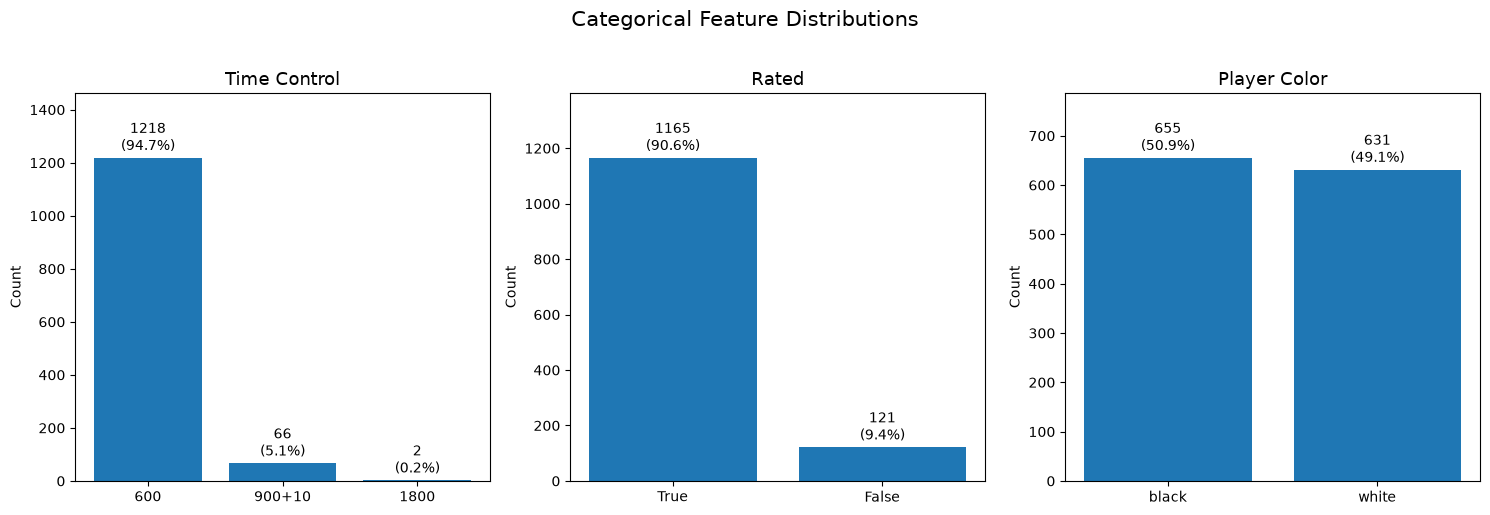

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = ['time_control', 'rated', 'player_color']
titles = ['Time Control', 'Rated', 'Player Color']

for ax, col, title in zip(axes, cols, titles):
    counts = df[col].value_counts()
    percentages = counts / counts.sum() * 100

    bars = ax.bar(counts.index.astype(str), counts.values)

    for bar, count, pct in zip(bars, counts.values, percentages.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


In [5]:
for col in df.columns:
    if ('opening' in col):
        print(f"Number of distinct values in {col} column: {df[col].nunique()}")

Number of distinct values in opening_type column: 110
Number of distinct values in opening column: 517
Number of distinct values in opening_family column: 52


In [6]:
df[['num_moves', 'avg_time_per_move']].describe().T

,count,mean,std,min,25%,50%,75%,max
num_moves,1286.0,75.232504,35.225317,3.00,49.250000,71.000000,97.000000,217.00
avg_time_per_move,1286.0,11.206131,4.258987,1.85,8.348204,10.673779,13.503653,34.38


In [7]:
df[['player_rating', 'opponent_rating']].describe().T

,count,mean,std,min,25%,50%,75%,max
player_rating,1286.0,1360.105754,133.287331,1093.0,1239.25,1341.5,1492.0,1617.0
opponent_rating,1286.0,1358.200622,164.337032,246.0,1234.25,1343.0,1492.0,2140.0


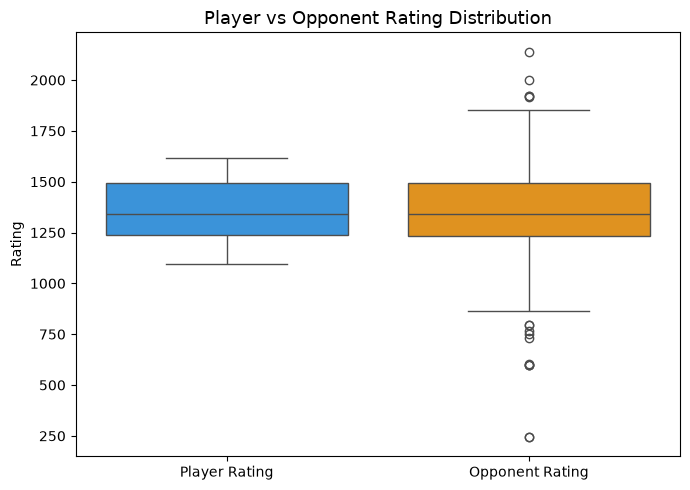

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

plot_df = df[['player_rating', 'opponent_rating']].melt(var_name='Type', value_name='Rating')
plot_df['Type'] = plot_df['Type'].map({'player_rating': 'Player Rating', 'opponent_rating': 'Opponent Rating'})

sns.boxplot(data=plot_df, x='Type', y='Rating', hue='Type', palette=['#2196F3', '#FF9800'], legend=False, ax=ax)

ax.set_title('Player vs Opponent Rating Distribution', fontsize=13)
ax.set_xlabel('')
plt.tight_layout()
plt.show()


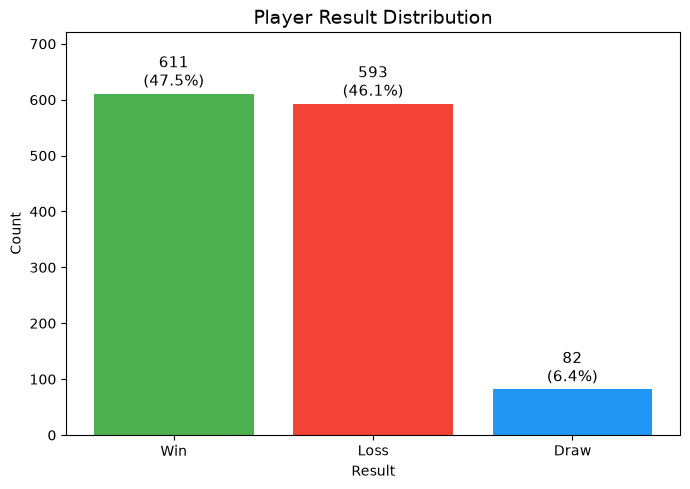

In [9]:
counts = df['player_result'].value_counts()
percentages = df['player_result'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values, color=['#4CAF50', '#F44336', '#2196F3'])

for bar, count, pct in zip(bars, counts.values, percentages.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Player Result Distribution', fontsize=14)
ax.set_xlabel('Result')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()


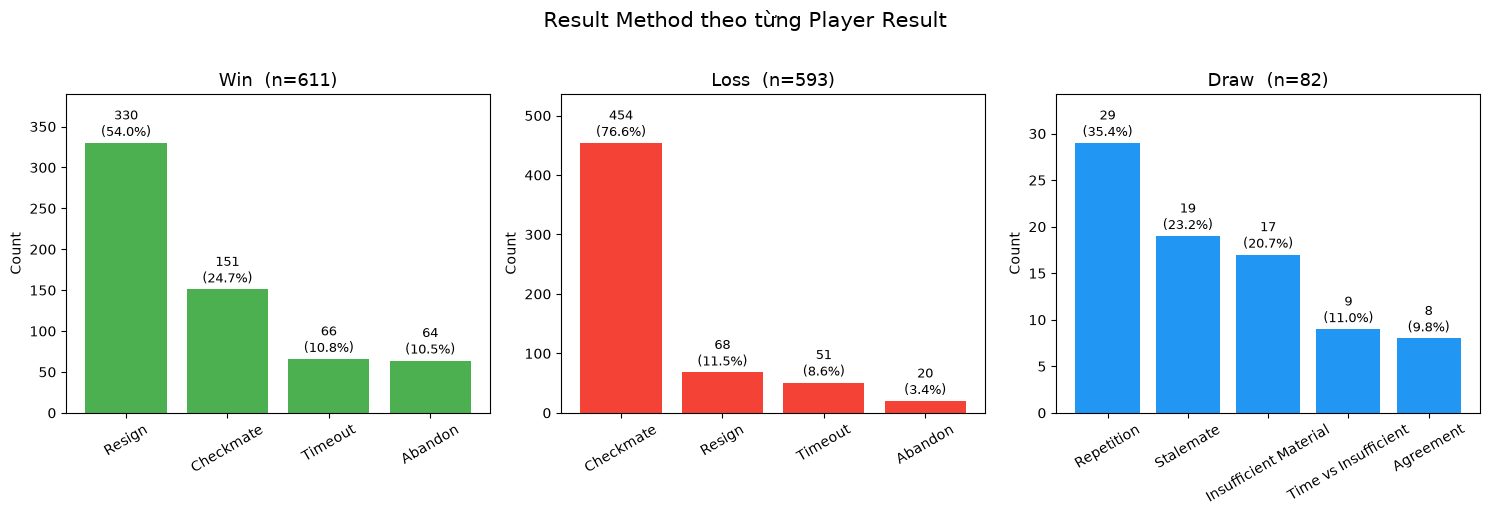

In [10]:
results = [r for r in ['Win', 'Loss', 'Draw'] if r in df['player_result'].unique()]
colors = {'Win': '#4CAF50', 'Draw': '#2196F3', 'Loss': '#F44336'}

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):
    sub = df[df['player_result'] == result]
    counts = sub['result_method'].value_counts()
    pct = counts / counts.sum() * 100

    bars = ax.bar(counts.index, counts.values, color=colors[result])
    for bar, c, p in zip(bars, counts.values, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                f'{c}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'{result}  (n={len(sub)})', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.18)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Result Method theo từng Player Result', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


##### **Feature Engineering**

In [11]:
df_fe = df.copy()
df_fe['start_time'] = pd.to_datetime(df_fe['start_time'])
df_fe['end_time']   = pd.to_datetime(df_fe['end_time'])
df_fe['duration (seconds)'] = (df_fe['end_time'] - df_fe['start_time']).dt.total_seconds()
df_fe = df_fe[df_fe['time_control'] != '1800'].reset_index(drop=True)
# ECO category: A=flank, B=semi-open, C=open, D=closed, E=Indian
df_fe['eco_category'] = df_fe['opening_type'].str[0]
df_fe = df_fe.drop(columns=['opening_type', 'opening'])

hours = df_fe['start_time'].dt.hour
labels = ['00-03', '03-06', '06-09', '09-12', '12-15', '15-18', '18-21', '21-00']

df_fe['time_of_day_bin'] = pd.Categorical.from_codes(hours // 3, categories=labels, ordered=True)
df_fe['rating_diff'] = df_fe['player_rating'] - df_fe['opponent_rating']

df_fe = df_fe.sort_values('end_time').reset_index(drop=True)

# 1) time_from_the_last_game (phút): start_time trận này - end_time trận liền trước.
#    Trận đầu tiên không có trận trước -> NaN.
df_fe['time_from_the_last_game'] = (
    (df_fe['start_time'] - df_fe['end_time'].shift(1)).dt.total_seconds() / 60
)

# 2) game_played_in_the_same_day: số trận đã chơi trong ngày (theo start_time),
#    KHÔNG tính trận đang xét. Trận đầu trong ngày = 0.
df_fe['game_played_in_the_same_day'] = (
    df_fe.groupby(df_fe['start_time'].dt.date).cumcount()
)

# 3) Hai cột nhị phân: đúng 3 trận NGAY LIỀN TRƯỚC toàn thắng / toàn thua
#    (Draw làm gãy chuỗi; những trận chưa đủ 3 trận trước -> 0).
is_win  = (df_fe['player_result'] == 'Win').astype(int)
is_loss = (df_fe['player_result'] == 'Loss').astype(int)

df_fe['last achieved 3-game win streak']  = is_win.shift(1).rolling(3).sum().eq(3).astype(int)
df_fe['last suffered 3-game loss streak'] = is_loss.shift(1).rolling(3).sum().eq(3).astype(int)

df_fe

,start_time,end_time,time_control,rated,opening_family,num_moves,avg_time_per_move,player_color,player_rating,opponent_rating,...,result_method,rating_change,duration (seconds),eco_category,time_of_day_bin,rating_diff,time_from_the_last_game,game_played_in_the_same_day,last achieved 3-game win streak,last suffered 3-game loss streak
0,2025-01-02 05:55:56,2025-01-02 06:01:32,600,True,Mieses Opening,63,5.226667,black,1093,1374,...,Abandon,0,336.0,A,03-06,-281,NaN,0,0,0
1,2025-02-10 05:23:10,2025-02-10 05:31:45,600,True,Queens Pawn Opening,39,12.436842,white,1217,1078,...,Resign,124,515.0,D,03-06,139,56121.633333,0,0,0
2,2025-02-10 05:31:58,2025-02-10 05:44:51,600,True,French Defense,70,17.250000,black,1308,1202,...,Resign,91,773.0,C,03-06,106,0.216667,1,0,0
3,2025-02-14 05:37:00,2025-02-14 05:50:33,600,True,Sicilian Defense,75,10.664865,white,1383,1306,...,Resign,75,813.0,B,03-06,77,5752.150000,0,0,0
4,2025-02-14 05:50:45,2025-02-14 06:00:07,600,True,Queens Gambit,45,14.976190,black,1308,1316,...,Checkmate,-75,562.0,D,03-06,-8,0.200000,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279,2026-06-17 14:02:53,2026-06-17 14:06:49,600,True,Kings Gambit,45,4.995238,black,1573,1586,...,Checkmate,-8,236.0,C,12-15,-13,0.083333,20,0,0
1280,2026-06-17 14:06:53,2026-06-17 14:19:35,600,True,Sicilian Defense,114,6.333929,white,1565,1596,...,Checkmate,-8,762.0,B,12-15,-31,0.066667,21,0,0
1281,2026-06-17 14:20:21,2026-06-17 14:29:10,600,True,Queens Pawn Opening,51,10.058333,black,1557,1563,...,Checkmate,-8,529.0,D,12-15,-6,0.766667,22,0,1
1282,2026-06-19 06:07:38,2026-06-19 06:16:57,600,True,Ponziani Opening,71,8.922857,white,1565,1562,...,Abandon,8,559.0,C,06-09,3,2378.466667,0,0,1


In [12]:
df_fe.to_csv(FEATURE_DATA_PATH)
print(f'Saved: {FEATURE_DATA_PATH}  |  Shape: {df_fe.shape}')

Saved: data/processed/thien3703_rapid_games_features.csv  |  Shape: (1284, 21)
